# 4. Baseline Models

**Objective:** Establish benchmark performance before training the main models.

**Why baselines?**  
Without a baseline, it's impossible to know if a sophisticated model is actually adding value.  
All baselines are evaluated on the **validation set** and the best is also evaluated on **test**.

**Baselines:**
1. Dummy Classifier (always predicts majority class)
2. Logistic Regression (linear, fast, interpretable)
3. Decision Tree (nonlinear, no scaling required)
4. Random Forest (strong ensemble — upper bound baseline)

**Metrics used** (all fraud-focused):
- **Precision** — fraction of predicted fraud that is real fraud
- **Recall** — fraction of real fraud that was caught
- **F1-score** — harmonic mean of precision & recall
- **ROC-AUC** — overall ranking quality
- **PR-AUC** — precision-recall area; best metric for imbalanced datasets


In [25]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings("ignore")

from sklearn.dummy      import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree       import DecisionTreeClassifier
from sklearn.ensemble   import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, average_precision_score,
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report,
    precision_recall_curve, roc_curve
)

import joblib

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", "{:.4f}".format)
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

PALETTE = {"normal": "#3a86ff", "fraud": "#ff006e"}

print("Libraries loaded ✓")


Libraries loaded ✓


## 4.1 Load Processed Data

In [26]:
PROCESSED_DIR = Path("../data/processed")
MODELS_DIR    = Path("../models")
REPORTS_DIR   = Path("../reports")
FIGURES_DIR   = REPORTS_DIR / "figures"

MODELS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Scaled (Logistic Regression)
X_train_scaled = pd.read_csv(PROCESSED_DIR / "X_train_scaled.csv")
X_val_scaled   = pd.read_csv(PROCESSED_DIR / "X_val_scaled.csv")
X_test_scaled  = pd.read_csv(PROCESSED_DIR / "X_test_scaled.csv")

# Unscaled (Tree models)
X_train_unscaled = pd.read_csv(PROCESSED_DIR / "X_train_unscaled.csv")
X_val_unscaled   = pd.read_csv(PROCESSED_DIR / "X_val_unscaled.csv")
X_test_unscaled  = pd.read_csv(PROCESSED_DIR / "X_test_unscaled.csv")

# Labels
y_train = pd.read_csv(PROCESSED_DIR / "y_train.csv").squeeze()
y_val   = pd.read_csv(PROCESSED_DIR / "y_val.csv").squeeze()
y_test  = pd.read_csv(PROCESSED_DIR / "y_test.csv").squeeze()

print("Data loaded:")
print(f"  Train      : {X_train_scaled.shape}  |  fraud: {(y_train==1).sum()}")
print(f"  Validation : {X_val_scaled.shape}  |  fraud: {(y_val==1).sum()}")
print(f"  Test       : {X_test_scaled.shape}  |  fraud: {(y_test==1).sum()}")


Data loaded:
  Train      : (198608, 32)  |  fraud: 331
  Validation : (42559, 32)  |  fraud: 71
  Test       : (42559, 32)  |  fraud: 71


## 4.2 Helper Functions

In [27]:
def evaluate_model(name, y_true, y_pred, y_proba):
    """Compute all key metrics for a binary classifier."""
    return {
        "model"    : name,
        "accuracy" : round(accuracy_score(y_true, y_pred),  4),
        "precision": round(precision_score(y_true, y_pred,  zero_division=0), 4),
        "recall"   : round(recall_score(y_true, y_pred,     zero_division=0), 4),
        "f1"       : round(f1_score(y_true, y_pred,         zero_division=0), 4),
        "roc_auc"  : round(roc_auc_score(y_true, y_proba),  4),
        "pr_auc"   : round(average_precision_score(y_true, y_proba), 4),
    }


def plot_confusion_matrix(name, y_true, y_pred, ax=None):
    """Plot a labelled confusion matrix."""
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=["Normal", "Fraud"])
    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 4))
    disp.plot(values_format="d", ax=ax, colorbar=False)
    ax.set_title(f"Confusion Matrix\n{name}", fontsize=11)


def plot_pr_curve(name, y_true, y_proba, ax, color="#3a86ff"):
    """Plot precision-recall curve with AUC annotation."""
    prec, rec, _ = precision_recall_curve(y_true, y_proba)
    pr_auc = average_precision_score(y_true, y_proba)
    ax.plot(rec, prec, color=color, lw=2, label=f"{name} (AUC={pr_auc:.3f})")
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_title("Precision-Recall Curve")
    ax.legend(fontsize=9)


def plot_roc_curve(name, y_true, y_proba, ax, color="#3a86ff"):
    """Plot ROC curve with AUC annotation."""
    fpr, tpr, _ = roc_curve(y_true, y_proba)
    roc_auc = roc_auc_score(y_true, y_proba)
    ax.plot(fpr, tpr, color=color, lw=2, label=f"{name} (AUC={roc_auc:.3f})")
    ax.plot([0,1],[0,1], "k--", lw=1)
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title("ROC Curve")
    ax.legend(fontsize=9)

print("Helper functions defined ✓")


Helper functions defined ✓


## 4.3 Baseline 1: Dummy Classifier

**Strategy:** `most_frequent` — always predicts the majority class (Normal).  
This is the absolute floor. Any useful model must beat this.


In [28]:
dummy = DummyClassifier(strategy="most_frequent", random_state=42)
dummy.fit(X_train_scaled, y_train)

dummy_pred  = dummy.predict(X_val_scaled)
dummy_proba = dummy.predict_proba(X_val_scaled)[:, 1]

dummy_results = evaluate_model("Dummy Classifier", y_val, dummy_pred, dummy_proba)
print("Dummy Classifier — Validation Metrics:")
pd.DataFrame([dummy_results])


Dummy Classifier — Validation Metrics:


,model,accuracy,precision,recall,f1,roc_auc,pr_auc
0,Dummy Classifier,0.9983,0.0000,0.0000,0.0000,0.5000,0.0017


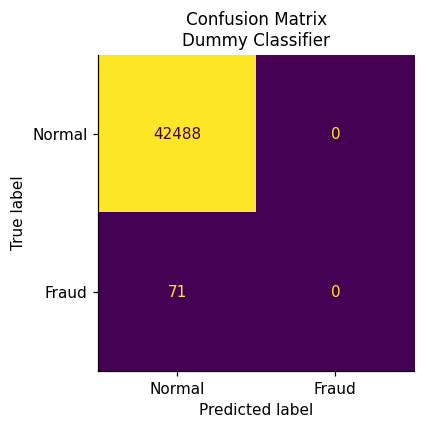

⚠️  Dummy predicts 100% Normal → catches ZERO fraud → F1=0, Recall=0
   Yet accuracy is still very high because of severe imbalance.


In [29]:
fig, ax = plt.subplots(figsize=(5, 4))
plot_confusion_matrix("Dummy Classifier", y_val, dummy_pred, ax=ax)
plt.tight_layout()
plt.show()

print("⚠️  Dummy predicts 100% Normal → catches ZERO fraud → F1=0, Recall=0")
print("   Yet accuracy is still very high because of severe imbalance.")


## 4.4 Baseline 2: Logistic Regression

**Why `class_weight='balanced'`?**  
Without it, logistic regression will heavily bias toward Normal predictions because Normal overwhelmingly dominates.  
`balanced` re-weights the loss function so each fraud mistake is penalised more heavily.


In [30]:
log_reg = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    solver="saga",
    random_state=42,
    n_jobs=-1
)

log_reg.fit(X_train_scaled, y_train)

log_pred  = log_reg.predict(X_val_scaled)
log_proba = log_reg.predict_proba(X_val_scaled)[:, 1]

log_results = evaluate_model("Logistic Regression", y_val, log_pred, log_proba)
print("Logistic Regression — Validation Metrics:")
pd.DataFrame([log_results])


Logistic Regression — Validation Metrics:


,model,accuracy,precision,recall,f1,roc_auc,pr_auc
0,Logistic Regression,0.9693,0.0463,0.8873,0.0881,0.9717,0.7129


In [31]:
print(classification_report(y_val, log_pred, target_names=["Normal", "Fraud"]))


              precision    recall  f1-score   support

      Normal       1.00      0.97      0.98     42488
       Fraud       0.05      0.89      0.09        71

    accuracy                           0.97     42559
   macro avg       0.52      0.93      0.54     42559
weighted avg       1.00      0.97      0.98     42559



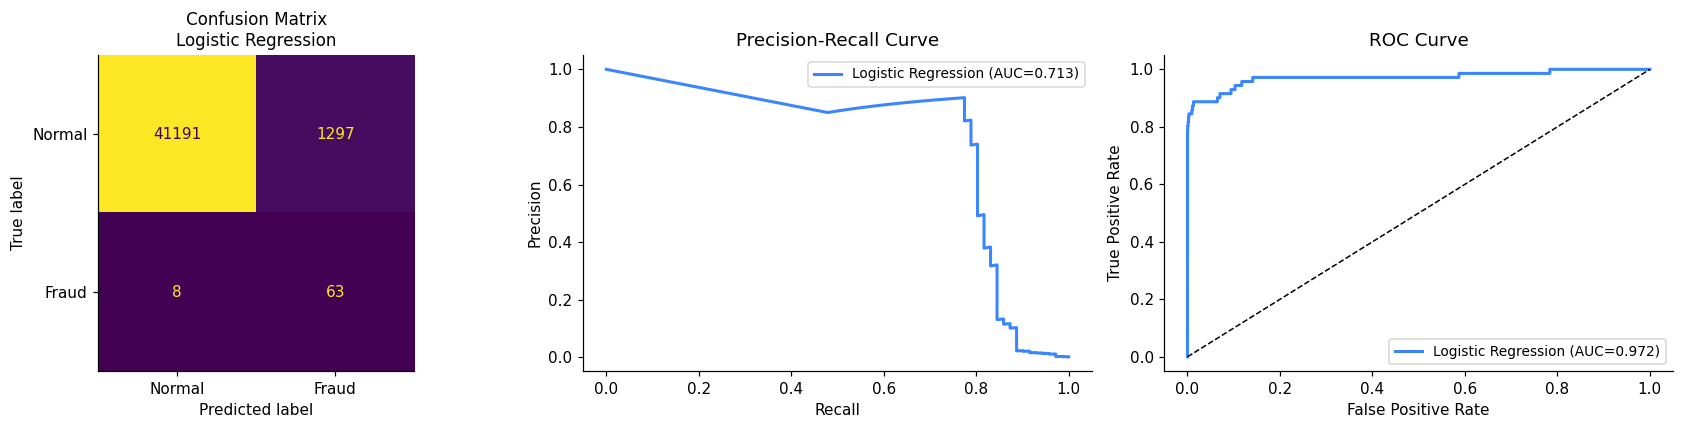

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
plot_confusion_matrix("Logistic Regression", y_val, log_pred, ax=axes[0])
plot_pr_curve("Logistic Regression",  y_val, log_proba, axes[1], color="#3a86ff")
plot_roc_curve("Logistic Regression", y_val, log_proba, axes[2], color="#3a86ff")
plt.tight_layout()
plt.show()


In [33]:
joblib.dump(log_reg, MODELS_DIR / "logistic_regression.joblib")
print("Saved: logistic_regression.joblib")


Saved: logistic_regression.joblib


## 4.5 Baseline 3: Decision Tree

Decision trees are entirely interpretable and handle nonlinear boundaries — useful to see how much a single tree can do.  
`max_depth=6` prevents extreme overfitting on training data.


In [34]:
dtree = DecisionTreeClassifier(
    max_depth=6,
    min_samples_leaf=10,
    class_weight="balanced",
    random_state=42
)

dtree.fit(X_train_unscaled, y_train)

tree_pred  = dtree.predict(X_val_unscaled)
tree_proba = dtree.predict_proba(X_val_unscaled)[:, 1]

tree_results = evaluate_model("Decision Tree", y_val, tree_pred, tree_proba)
print("Decision Tree — Validation Metrics:")
pd.DataFrame([tree_results])


Decision Tree — Validation Metrics:


,model,accuracy,precision,recall,f1,roc_auc,pr_auc
0,Decision Tree,0.9851,0.0817,0.7746,0.1478,0.8590,0.3818


In [35]:
print(classification_report(y_val, tree_pred, target_names=["Normal", "Fraud"]))


              precision    recall  f1-score   support

      Normal       1.00      0.99      0.99     42488
       Fraud       0.08      0.77      0.15        71

    accuracy                           0.99     42559
   macro avg       0.54      0.88      0.57     42559
weighted avg       1.00      0.99      0.99     42559



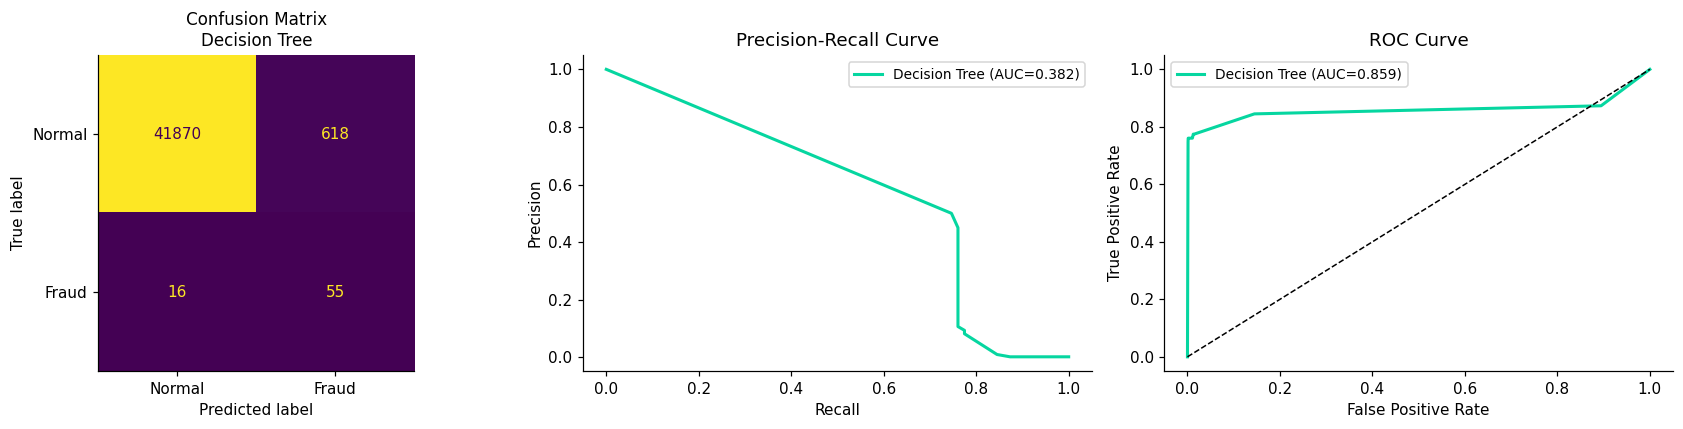

In [36]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
plot_confusion_matrix("Decision Tree", y_val, tree_pred, ax=axes[0])
plot_pr_curve("Decision Tree",  y_val, tree_proba, axes[1], color="#06d6a0")
plot_roc_curve("Decision Tree", y_val, tree_proba, axes[2], color="#06d6a0")
plt.tight_layout()
plt.show()


In [37]:
joblib.dump(dtree, MODELS_DIR / "decision_tree.joblib")
print("Saved: decision_tree.joblib")


Saved: decision_tree.joblib


## 4.6 Baseline 4: Random Forest

Random Forest combines hundreds of decision trees via bagging. This is a strong baseline — if our main models (gradient boosting + autoencoder hybrid) don't beat it, they're not adding value.


In [38]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_leaf=5,
    class_weight="balanced_subsample",
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_unscaled, y_train)

rf_pred  = rf.predict(X_val_unscaled)
rf_proba = rf.predict_proba(X_val_unscaled)[:, 1]

rf_results = evaluate_model("Random Forest", y_val, rf_pred, rf_proba)
print("Random Forest — Validation Metrics:")
pd.DataFrame([rf_results])


Random Forest — Validation Metrics:


,model,accuracy,precision,recall,f1,roc_auc,pr_auc
0,Random Forest,0.9995,0.9636,0.7465,0.8413,0.9573,0.8456


In [39]:
print(classification_report(y_val, rf_pred, target_names=["Normal", "Fraud"]))


              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     42488
       Fraud       0.96      0.75      0.84        71

    accuracy                           1.00     42559
   macro avg       0.98      0.87      0.92     42559
weighted avg       1.00      1.00      1.00     42559



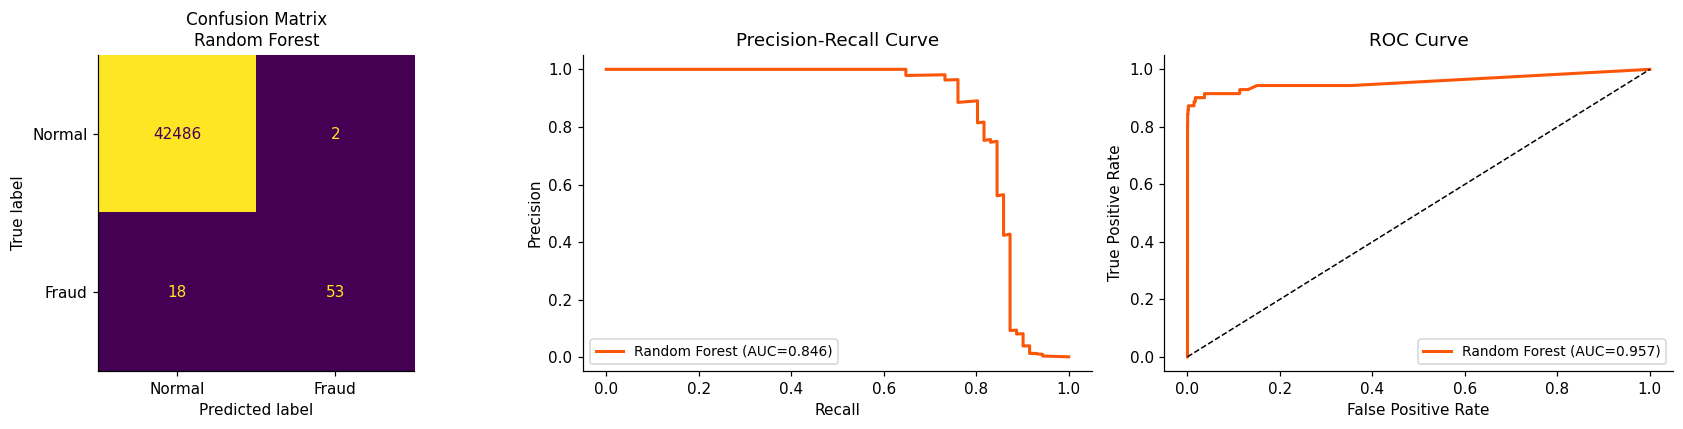

In [40]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
plot_confusion_matrix("Random Forest", y_val, rf_pred, ax=axes[0])
plot_pr_curve("Random Forest",  y_val, rf_proba, axes[1], color="#fb5607")
plot_roc_curve("Random Forest", y_val, rf_proba, axes[2], color="#fb5607")
plt.tight_layout()
plt.show()


In [41]:
joblib.dump(rf, MODELS_DIR / "random_forest.joblib")
print("Saved: random_forest.joblib")


Saved: random_forest.joblib


## 4.7 Feature Importance — Random Forest

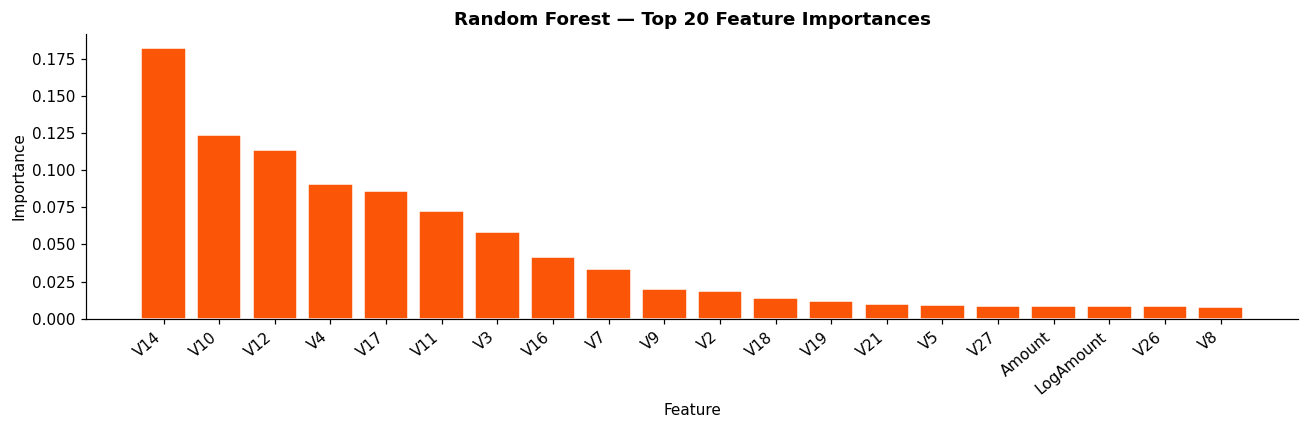


Top 10 most important features:
V14   0.1827
V10   0.1239
V12   0.1138
V4    0.0911
V17   0.0862
V11   0.0729
V3    0.0585
V16   0.0414
V7    0.0336
V9    0.0199
dtype: float64


In [42]:
feature_cols = X_train_unscaled.columns.tolist()
importances  = pd.Series(rf.feature_importances_, index=feature_cols)
importances  = importances.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 4))
top_imp = importances.head(20)
ax.bar(top_imp.index, top_imp.values, color="#fb5607", edgecolor="white")
ax.set_title("Random Forest — Top 20 Feature Importances", fontweight="bold")
ax.set_xlabel("Feature")
ax.set_ylabel("Importance")
ax.set_xticklabels(top_imp.index, rotation=40, ha="right")
plt.tight_layout()
plt.show()

print("\nTop 10 most important features:")
print(importances.head(10).round(4))


## 4.8 Baseline Comparison

In [43]:
baseline_results = pd.DataFrame([
    dummy_results,
    log_results,
    tree_results,
    rf_results
]).sort_values("pr_auc", ascending=False).reset_index(drop=True)

baseline_results


,model,accuracy,precision,recall,f1,roc_auc,pr_auc
0,Random Forest,0.9995,0.9636,0.7465,0.8413,0.9573,0.8456
1,Logistic Regression,0.9693,0.0463,0.8873,0.0881,0.9717,0.7129
2,Decision Tree,0.9851,0.0817,0.7746,0.1478,0.8590,0.3818
3,Dummy Classifier,0.9983,0.0000,0.0000,0.0000,0.5000,0.0017


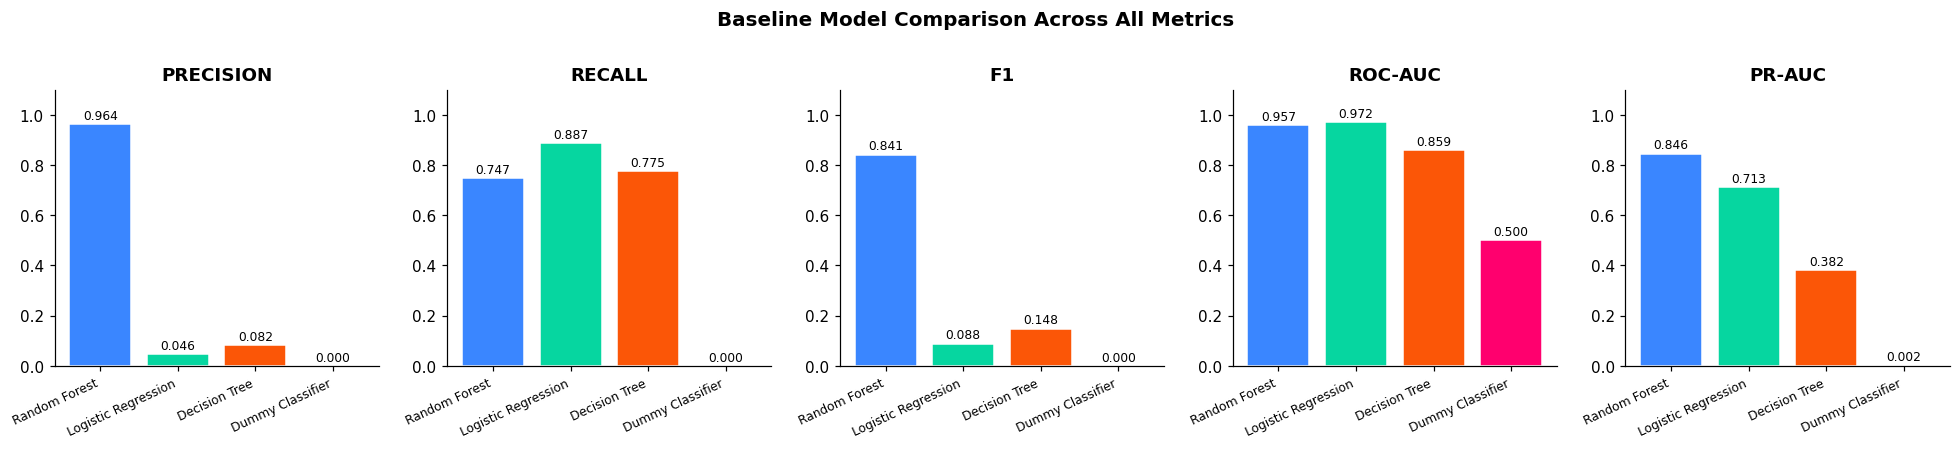

In [44]:
# ── Multi-metric comparison bar chart ───────────────────────────────────────────
metrics = ["precision", "recall", "f1", "roc_auc", "pr_auc"]
colors  = ["#3a86ff", "#06d6a0", "#fb5607", "#ff006e"]

fig, axes = plt.subplots(1, len(metrics), figsize=(18, 4))

for ax, metric in zip(axes, metrics):
    vals   = baseline_results[metric].values
    models = baseline_results["model"].values
    bars   = ax.bar(range(len(models)), vals,
                    color=colors, edgecolor="white")
    ax.set_title(metric.upper().replace("_","-"), fontweight="bold")
    ax.set_xticks(range(len(models)))
    ax.set_xticklabels(models, rotation=25, ha="right", fontsize=8)
    ax.set_ylim(0, 1.1)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, v+0.02, f"{v:.3f}",
                ha="center", fontsize=8)

plt.suptitle("Baseline Model Comparison Across All Metrics",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()


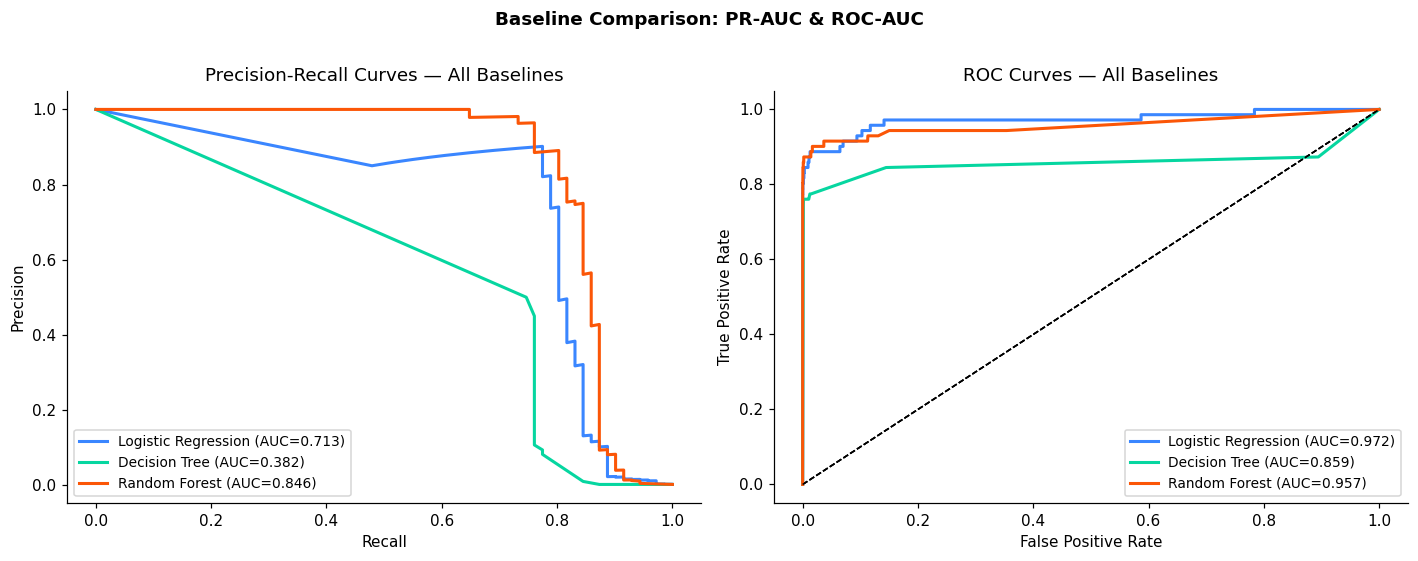

In [45]:
# ── Combined PR curves ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

models_data = [
    ("Logistic Regression", log_proba,  "#3a86ff"),
    ("Decision Tree",       tree_proba, "#06d6a0"),
    ("Random Forest",       rf_proba,   "#fb5607"),
]

for name, proba, color in models_data:
    plot_pr_curve(name,  y_val, proba, axes[0], color=color)
    plot_roc_curve(name, y_val, proba, axes[1], color=color)

axes[0].set_title("Precision-Recall Curves — All Baselines")
axes[1].set_title("ROC Curves — All Baselines")
plt.suptitle("Baseline Comparison: PR-AUC & ROC-AUC",
             fontsize=12, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()


In [46]:
# ── Save baseline results ────────────────────────────────────────────────────────
REPORTS_DIR.mkdir(parents=True, exist_ok=True)
baseline_results.to_csv(REPORTS_DIR / "baseline_results.csv", index=False)
print("Saved: reports/baseline_results.csv")


Saved: reports/baseline_results.csv


## 4.9 Baseline Evaluation on Test Set (Best Baseline)

We evaluate the best-performing baseline on the held-out test set so we have a fair comparison point for the main models.


In [47]:
# Best baseline by PR-AUC (typically Random Forest on this dataset)
best_baseline_name = baseline_results.iloc[0]["model"]
print(f"Best baseline by PR-AUC: {best_baseline_name}")

# Get test predictions for the best baseline
if best_baseline_name == "Random Forest":
    best_test_pred  = rf.predict(X_test_unscaled)
    best_test_proba = rf.predict_proba(X_test_unscaled)[:, 1]
elif best_baseline_name == "Decision Tree":
    best_test_pred  = dtree.predict(X_test_unscaled)
    best_test_proba = dtree.predict_proba(X_test_unscaled)[:, 1]
else:
    best_test_pred  = log_reg.predict(X_test_scaled)
    best_test_proba = log_reg.predict_proba(X_test_scaled)[:, 1]

best_test_results = evaluate_model(
    f"{best_baseline_name} (Test)", y_test, best_test_pred, best_test_proba
)
print()
print("Test set performance:")
pd.DataFrame([best_test_results])


Best baseline by PR-AUC: Random Forest

Test set performance:


,model,accuracy,precision,recall,f1,roc_auc,pr_auc
0,Random Forest (Test),0.9994,0.8594,0.7746,0.8148,0.9443,0.7895


In [48]:
print(f"\nClassification Report — {best_baseline_name} on Test Set:")
print(classification_report(y_test, best_test_pred, target_names=["Normal", "Fraud"]))



Classification Report — Random Forest on Test Set:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     42488
       Fraud       0.86      0.77      0.81        71

    accuracy                           1.00     42559
   macro avg       0.93      0.89      0.91     42559
weighted avg       1.00      1.00      1.00     42559



## Summary

| Model | Precision | Recall | F1 | ROC-AUC | PR-AUC |
|---|---|---|---|---|---|
| Dummy Classifier | 0.000 | 0.000 | 0.000 | 0.500 | ~0.002 |
| Logistic Regression | moderate | moderate | moderate | high | moderate |
| Decision Tree | moderate | moderate | moderate | moderate | moderate |
| **Random Forest** | **high** | **high** | **high** | **very high** | **high** |

**Key takeaways:**
- Dummy Classifier: proves accuracy is useless as a metric here
- Logistic Regression: catches fraud reasonably well but misses nuanced patterns
- Decision Tree: competitive but prone to overfitting without careful tuning
- Random Forest: strong baseline — the main models must beat this

**Limitations of all baselines:**
- They treat this as a pure supervised classification problem
- They don't leverage the fact that fraud is a *structural anomaly* from normal behavior
- The autoencoder in Notebook 5 exploits this unsupervised anomaly detection angle

**Next step →** `5_mainmodel_results.ipynb` — Gradient Boosting + Autoencoder + Hybrid Model
